***
***
# ***INSTRUCTOR EFFECTIVENESS PROJECT***

***
***

## ABOUT DATASET

This was an assignment dataset which was related to instructer effectiveness dataset which was provided by an Edtech Company where I need to analyse the data and work on this project according to their guidelines and after that I need to answer their questions.

**Problem Statement***


You are working with an EdTech platform that runs the same course across multiple batches
taught by different instructors.
Each instructor may teach:

● Multiple batches

● The same course across different batches

● Different courses across time
The company wants to better understand instructor effectiveness using available data from
learner outcomes, engagement, and feedback.
Your task is to analyze the data, define instructor effectiveness, and build an ML model to
predict instructor effectiveness tiers.
There is no single correct answer.
We are more interested in how you think than the final model accuracy.


### DATA DESCRIPTION

* Each row represents one course batch
* Multiple rows may belong to the same instructor


***batch_id***  -   Unique ID for a course batch

***instructor_id*** - Unique instructor identifier

**course_id** -  Course identifier

**completion_rate** -  Fraction of learners who completed the course (0–1)

**dropout_rate** -  Fraction of learners who dropped out (0–1)

**avg_score_improvement** -  Average improvement from pre- to post-assessment

**avg_quiz_score** -  Average quiz score for the batch

**avg_watch_time** -  Normalized average video watch time (0–1)

**assignment_submission_rate** -  Fraction of learners submitting assignments

**forum_activity_rate** -  Fraction of learners active on discussion forums

**avg_feedback_score** -  Average learner feedback rating (1–5)

**feedback_response_rate** -  Fraction of learners who submitted feedback


In [117]:
# Importing Libraries

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder,label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,f1_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

***

## STEP 1: EXPLORATORY DATA ANALYSIS

#### DATA EXPLORATION

In [118]:
# Loading the dataset
data = pd.read_csv('instructer_dataset.csv')


In [119]:
# Top 5 rows of the dataset
data.head()


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [120]:
# Bottom 5 rows of the dataset
data.tail()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
1995,B_1131,I_047,C_17,0.589309,19.227979,46.242023,0.433437,0.848756,0.641781,0.261656,4.339478,0.643116
1996,B_1295,I_037,C_25,0.980000,36.737265,93.249093,0.103561,1.000000,0.688175,0.375195,4.912936,0.959988
1997,B_0861,I_033,C_06,0.531447,24.907878,83.990693,0.512266,0.918924,0.598276,0.271701,4.211113,0.773437
1998,B_1460,I_069,C_10,0.641025,22.395362,80.044231,0.317231,0.558183,0.575629,0.135500,4.182141,0.962627
1999,B_1127,I_045,C_22,0.300000,23.101794,86.891153,0.700000,0.563834,0.538691,0.210189,4.420309,0.545611


In [121]:
# Rows and columns in the dataset

print(f"Number of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")

Number of rows: 2000
Number of columns: 12


In [122]:
# Column names in the dataset
print("Column names: \n ", 
      data.columns)

Column names: 
  Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')


In [123]:
# Looking For unique values in the dataset
for i in data.columns:
    print(f"Unique values in '{i}': {data[i].unique()}\n")    

Unique values in 'batch_id': ['B_1861' 'B_0354' 'B_1334' ... 'B_0861' 'B_1460' 'B_1127']

Unique values in 'instructor_id': ['I_044' 'I_119' 'I_050' 'I_024' 'I_001' 'I_026' 'I_082' 'I_009' 'I_114'
 'I_038' 'I_007' 'I_064' 'I_105' 'I_084' 'I_087' 'I_086' 'I_088' 'I_033'
 'I_032' 'I_117' 'I_111' 'I_039' 'I_100' 'I_018' 'I_021' 'I_085' 'I_010'
 'I_055' 'I_112' 'I_113' 'I_047' 'I_090' 'I_107' 'I_052' 'I_065' 'I_103'
 'I_096' 'I_028' 'I_045' 'I_115' 'I_079' 'I_027' 'I_092' 'I_110' 'I_020'
 'I_074' 'I_118' 'I_035' 'I_101' 'I_109' 'I_097' 'I_019' 'I_040' 'I_029'
 'I_075' 'I_036' 'I_002' 'I_043' 'I_025' 'I_013' 'I_023' 'I_071' 'I_081'
 'I_062' 'I_116' 'I_072' 'I_066' 'I_016' 'I_017' 'I_069' 'I_057' 'I_060'
 'I_098' 'I_034' 'I_014' 'I_058' 'I_046' 'I_059' 'I_022' 'I_041' 'I_011'
 'I_005' 'I_089' 'I_070' 'I_094' 'I_093' 'I_091' 'I_108' 'I_095' 'I_051'
 'I_080' 'I_063' 'I_102' 'I_012' 'I_106' 'I_068' 'I_048' 'I_003' 'I_077'
 'I_015' 'I_004' 'I_037' 'I_031' 'I_073' 'I_053' 'I_049' 'I_030' 'I_099'


#### Descriptive Analysis

In [124]:
# Data information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [125]:
# 5 point summary of data

data.describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


In [126]:
print("Unique instructor's id count:", data['instructor_id'].unique().shape[0])
print("Unique batch's id count:", data['batch_id'].unique().shape[0])
print("Unique course_id's id count:", data['course_id'].unique().shape[0])

Unique instructor's id count: 120
Unique batch's id count: 2000
Unique course_id's id count: 25


In [127]:
# Looking for Missing values in the dataset
print("Missing values in the dataset: \n", 
      data.isnull().sum().sum())

Missing values in the dataset: 
 0


In [128]:
# Looking for Duplicate values in the dataset
print("Duplicate values in the dataset: \n",
        data.duplicated().sum())        

Duplicate values in the dataset: 
 0


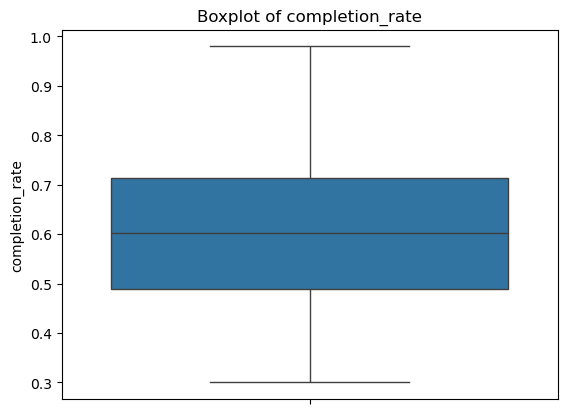

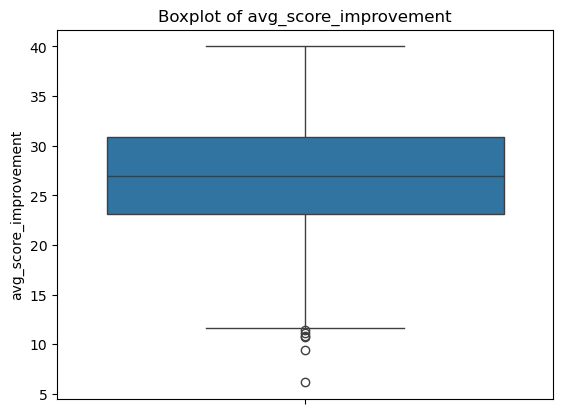

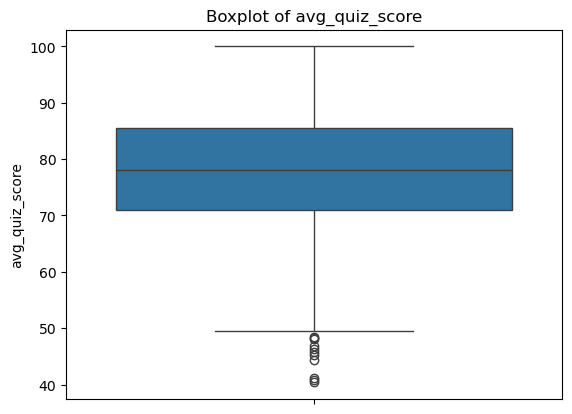

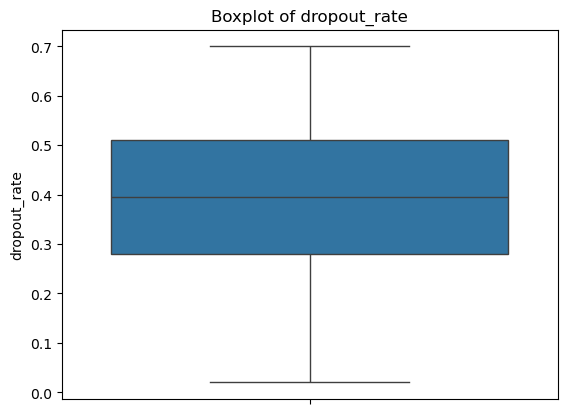

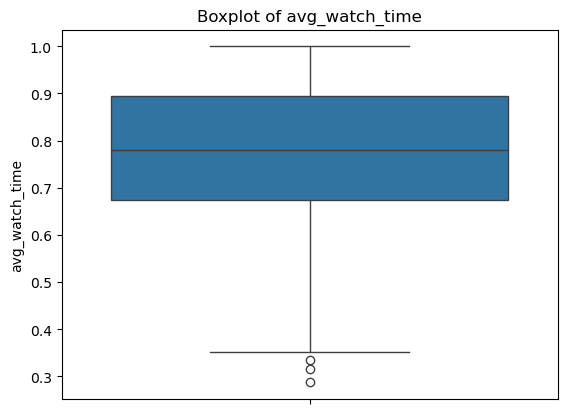

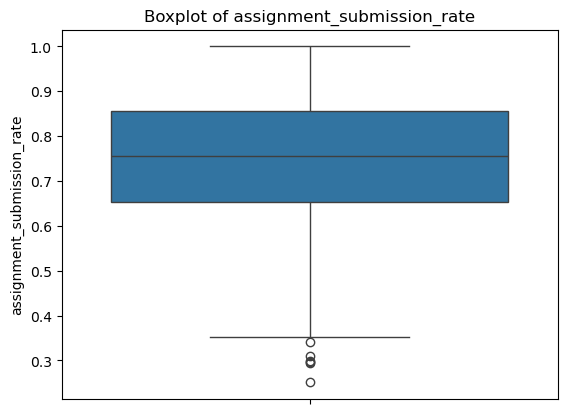

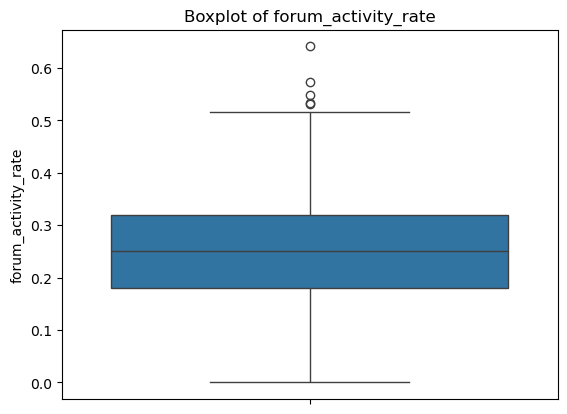

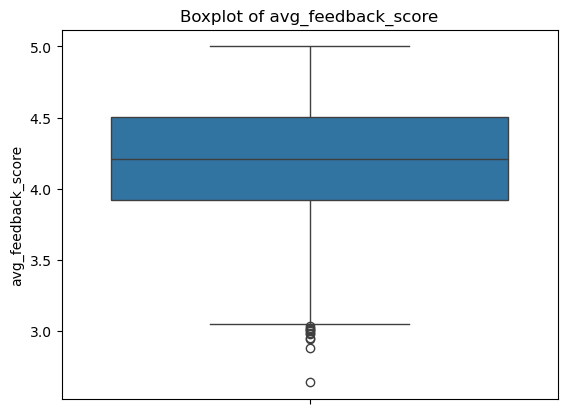

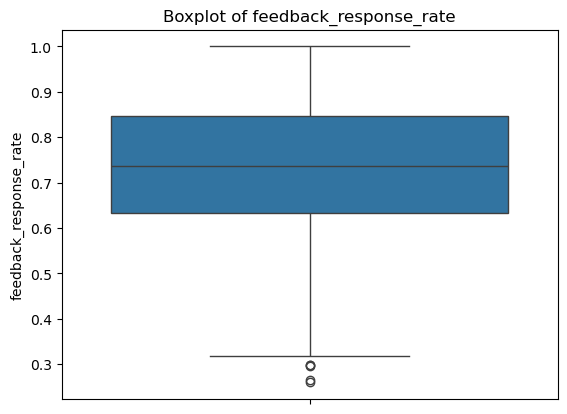

In [129]:
# Looking for outliers in the dataset

for i in data.columns[3:13]:
    sns.boxplot(data[i])
    plt.title(f"Boxplot of {i}")
    plt.show()
   


***

***Insights***

* By analysing the dataset I found the following information :
1) There is 2000 rows and 12 columns in the data
2) Every column in the data is in numerical type  there is no categorical variable in the data
3) All the columns have no missing values present . This shows we don't need to handle any missing values.
4) There is no duplicated values present in the data
5) There is some outliers present in variables like feedback_response_rate,average_feedback_score, forum_activity_rate which we need to handle . We will handle all those outliers after visualization so that we can't able to loose any information which can be represented through outliers.
6) We can find through id columns that there is 120 instructors who instructed all 2000 batches this shows each instructor instructed more than 1 batch .
7) There is also 25 courses for batches means more than 1 batch has same course which can be instructed by 1 instructor.

***

#### VISUALIZATION

In [130]:
num_cols = data.columns[3:13]

##### CORRELATION BETWEEN VARIABLES

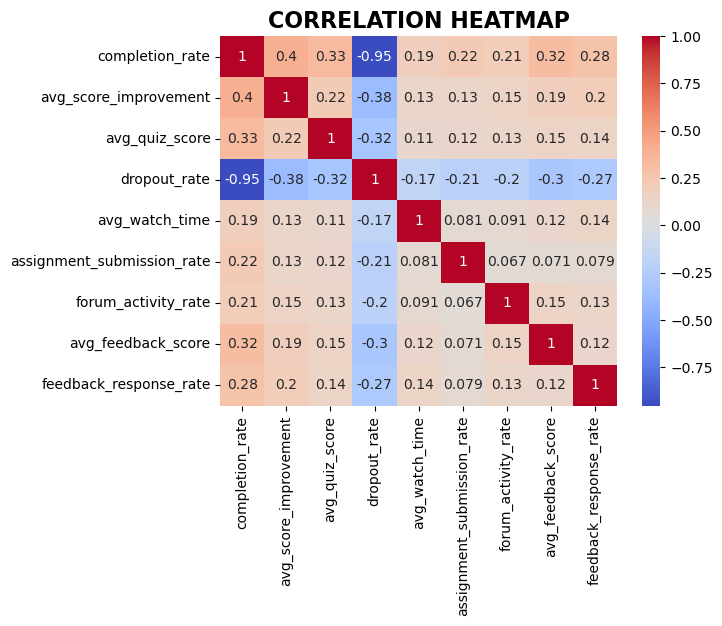

In [131]:
plt.figsize=(15,10)
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("CORRELATION HEATMAP",fontweight='bold', fontsize=16)
plt.show()

#### Dropout_Rate vs Completion Rate

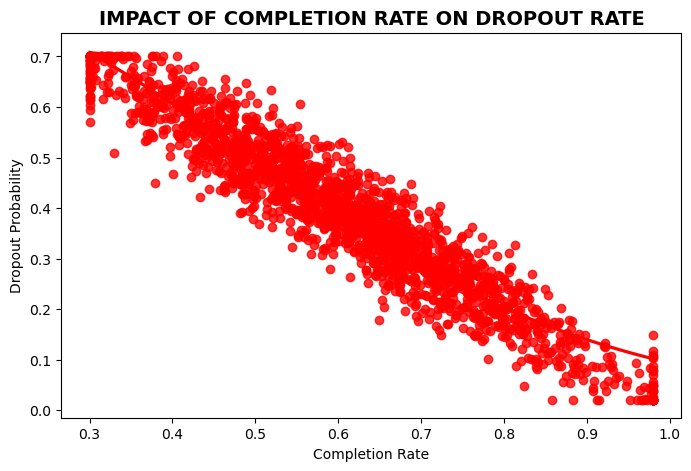

In [132]:
plt.figure(figsize=(8,5))
sns.regplot(x='completion_rate', y='dropout_rate', data=data, logistic=True, color='red')
plt.title("IMPACT OF COMPLETION RATE ON DROPOUT RATE",fontweight='bold', fontsize=14)
plt.xlabel("Completion Rate")
plt.ylabel("Dropout Probability")
plt.show()

***

***Insights***

After Visualizing this above correlation and the relation chart and found that there is no strong positive correlation between any two variable. But, I can see that there is strong negative correlation between dropout rate vs completion rate. This shows that when drop out rate increases completion rate goes to decrease sharply and vice versa. This means that if any batch has very less drop out rate there is high chances of completing the task in a very high rate.
Apart from there 2 columns rest of the variables have not much any relation.

***

### STEP2 : EXTRACTING COLUMN INSTRUCTOR EFFECTIVENESS SCORE

In [133]:
data.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

In [134]:
print("Unique instructor's id count:", data['instructor_id'].unique().shape[0])
print("Unique batch's id count:", data['batch_id'].unique().shape[0])
print("Unique course_id's id count:", data['course_id'].unique().shape[0])



Unique instructor's id count: 120
Unique batch's id count: 2000
Unique course_id's id count: 25


In [135]:
data.groupby(['instructor_id']).agg({'course_id':'nunique','batch_id':'count'}).reset_index()

# This table indicates that each instructor is teaching more than one course and more than one batch. 
# This suggests that the dataset contains information about multiple courses and batches for each instructor.

,instructor_id,course_id,batch_id
0,I_001,16,25
1,I_002,10,20
2,I_003,14,18
3,I_004,10,17
4,I_005,13,19
...,...,...,...
115,I_116,13,17
116,I_117,11,19
117,I_118,14,19
118,I_119,12,19


In [136]:
data[['completion_rate', 'avg_quiz_score', 'avg_feedback_score']].describe()

,completion_rate,avg_quiz_score,avg_feedback_score
count,2000.000000,2000.000000,2000.000000
mean,0.602808,77.956126,4.207134
std,0.159667,10.695618,0.419209
min,0.300000,40.386725,2.639915
25%,0.489260,70.897590,3.918986
50%,0.603091,78.020567,4.205989
75%,0.712797,85.444286,4.503437
max,0.980000,100.000000,5.000000


In [137]:
data.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


***

**Insights**

I found that for creating instructor effectiveness score column . I need to mostly focus on learner's outcome more than the scoring outcomes.

    - By taking variables like avg_watch_time, forum_activity_score,assignment_submission_rate indicates that the learners can learn in an effective way. So, I am giving more weightage to these variables than other variables for calculating instructor effectiveness score variable.
    
    - second most weightage to marks related columns like completion_rate,avg_score_improvement,avg_quiz_score and feedback score. This shows how much well both instructor and  learners did during the course.
    

According to me Learning Process is much more important than scoring good in assignment or exams . That's why I give less weightage to marks related columns
I use all those columns avg for calculating this column. Before creating this column I need to scale all the columns present in the data so that all the columns will be in a same range. This will help me to create instructor score in effective way.


As completion_rate and drop out rate have strong negative correlation I am only taking completion_rate for my further work.



For calculating instructor_effectiveness_score

instructor_score = w1* completion_rate + w2* avg_score_improvement + w3* avg_quiz_score .......

where w1,w2,w3... these all are the weights which I assign to these features based on my logic

***

#### FOR EXTRACTING COLUMN I NEED TO FIRST SCALE THE DATA

In [138]:
# creating copy of this dataset for further analysis

df = data.copy()

In [139]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [140]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,-1.896976,-2.241368,-0.412384,1.552124,-0.013382,0.254897,-1.410194,-1.052061,-1.361185
1,B_0354,I_119,C_06,0.340871,-0.728710,-0.060207,0.185700,-1.939317,1.657721,0.300646,1.891811,-0.016281
2,B_1334,I_050,C_03,-1.896976,-1.915647,0.150339,1.875263,1.387003,0.365554,-0.430223,-1.645768,-0.368779
3,B_0906,I_024,C_21,0.229901,-0.485574,1.995633,-0.370154,0.482109,-1.409480,0.557522,0.001059,1.763893
4,B_1290,I_001,C_08,-0.473018,0.707885,2.004808,0.775729,0.970658,0.761360,0.019771,0.522772,-0.266509


In [141]:
# Now I got the scaled values 

score_calculation = df.groupby('instructor_id')[['completion_rate', 'avg_score_improvement', 
                                                 'avg_quiz_score', 'avg_watch_time', 
                                                 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score']].mean().reset_index()



* As there is outlier present in the data but outliers are not much extreme because the diffence between mean and median is very less. 
So, I am using average for grouping the data .

- for columns avg_watch_time,avg_score_improvement,completion_rate,forum_activity_rate I am assigning weight as 0.15
- for columns avg_quiz_score,assignment_submission_rate I am assigning weight as 0.14
- for remaining columns I am taking weight of 0.12

In [142]:

score_calculation['instructor_effectiveness_score'] = (score_calculation['completion_rate'] * 0.15 +
                                        score_calculation['avg_score_improvement'] * 0.15 +
                                        score_calculation['avg_quiz_score'] * 0.14 +
                                        score_calculation['avg_watch_time'] * 0.15 +
                                        score_calculation['assignment_submission_rate'] * 0.14 +
                                        score_calculation['forum_activity_rate'] * 0.15 +
                                        score_calculation['avg_feedback_score'] * 0.12)

In [143]:
df = df.merge(score_calculation[['instructor_id', 'instructor_effectiveness_score']], 
              on='instructor_id', 
              how='left')

In [144]:
data = data.merge(score_calculation[['instructor_id', 'instructor_effectiveness_score']], 
              on='instructor_id', 
              how='left')

In [145]:
df.head(2)

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,instructor_effectiveness_score
0,B_1861,I_044,C_01,-1.896976,-2.241368,-0.412384,1.552124,-0.013382,0.254897,-1.410194,-1.052061,-1.361185,-1.106505
1,B_0354,I_119,C_06,0.340871,-0.728710,-0.060207,0.185700,-1.939317,1.657721,0.300646,1.891811,-0.016281,-0.007495


In [146]:
data.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,instructor_effectiveness_score
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193,-1.106505
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087,-0.007495
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433,-0.992981
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000,0.279097
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710,-0.100059


In [147]:
# Now we need too grouping this column so that we can categorize this into 3 categories

data['instructor_effectiveness_score'].describe()

count    2.000000e+03
mean     3.428369e-16
std      4.241301e-01
min     -1.117015e+00
25%     -2.821064e-01
50%     -1.109546e-02
75%      2.695123e-01
max      1.134890e+00
Name: instructor_effectiveness_score, dtype: float64

In [148]:
# Now we need to classify this into 3 categories low, medium and high

def classify_score(score):
    if score <= -0.28: # bottom 25% values
        return 'Low'
    elif score >= 0.27: # Top 25% values
        return 'High'
    else:
        return 'Medium'   # rest comes under medium category which will be between -0.28 to 0.27

df['effective_score_tier'] = df['instructor_effectiveness_score'].apply(classify_score)
data['effective_score_tier'] = data['instructor_effectiveness_score'].apply(classify_score)

In [149]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,instructor_effectiveness_score,effective_score_tier
0,B_1861,I_044,C_01,-1.896976,-2.241368,-0.412384,1.552124,-0.013382,0.254897,-1.410194,-1.052061,-1.361185,-1.106505,Low
1,B_0354,I_119,C_06,0.340871,-0.728710,-0.060207,0.185700,-1.939317,1.657721,0.300646,1.891811,-0.016281,-0.007495,Medium
2,B_1334,I_050,C_03,-1.896976,-1.915647,0.150339,1.875263,1.387003,0.365554,-0.430223,-1.645768,-0.368779,-0.992981,Low
3,B_0906,I_024,C_21,0.229901,-0.485574,1.995633,-0.370154,0.482109,-1.409480,0.557522,0.001059,1.763893,0.279097,High
4,B_1290,I_001,C_08,-0.473018,0.707885,2.004808,0.775729,0.970658,0.761360,0.019771,0.522772,-0.266509,-0.100059,Medium


In [150]:
# Now I need to find out how many instructors are in each category

df.groupby('effective_score_tier')['instructor_id'].nunique().reset_index()




,effective_score_tier,instructor_id
0,High,29
1,Low,31
2,Medium,60


In [151]:
print('-'*50 , 'INSIGHT FROM INSTRUCTOR EFFECTIVENESS SCORE COLUMN ' , '-'*50,'\n')

print("I used balanced distribution for categorizing the scores into low, medium, and high based on the quartiles of the instructor effectiveness scores. \n This approach helps me to identify instructors who are performing significantly better or worse than their peers, \n while also recognizing those who are in the middle range.")
        

print(" This shows that there are 30 instructors got high effective score \n This shows that learners who work under these 30 instructors learn much better than the other 2")
print(" The Number  of instructors whoo got low  effective score was 31 and who got medium was 59")
print(" This shows that Most of Instructors are in the score  of medium  and high scorers are very less than bot medium as well as low scorers")


-------------------------------------------------- INSIGHT FROM INSTRUCTOR EFFECTIVENESS SCORE COLUMN  -------------------------------------------------- 

I used balanced distribution for categorizing the scores into low, medium, and high based on the quartiles of the instructor effectiveness scores. 
 This approach helps me to identify instructors who are performing significantly better or worse than their peers, 
 while also recognizing those who are in the middle range.
 This shows that there are 30 instructors got high effective score 
 This shows that learners who work under these 30 instructors learn much better than the other 2
 The Number  of instructors whoo got low  effective score was 31 and who got medium was 59
 This shows that Most of Instructors are in the score  of medium  and high scorers are very less than bot medium as well as low scorers


#### Visualizing the data through Instructor effective score column

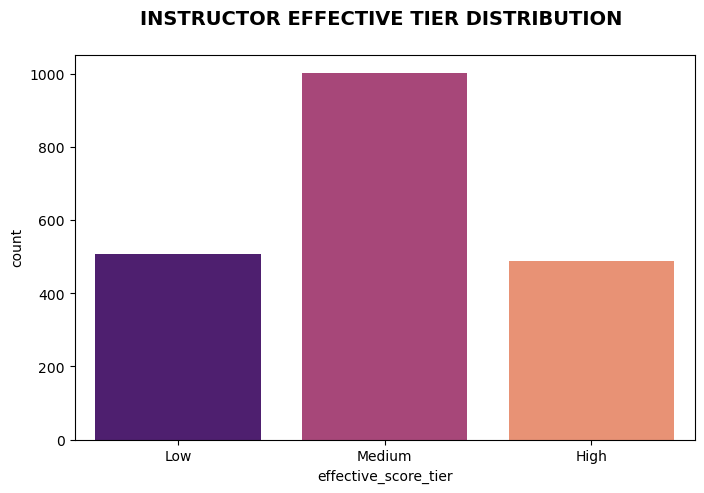

In [152]:
# Visualization of the distribution of instructor effectiveness scores

plt.figure(figsize=(8,5))
sns.countplot(data=data,x='effective_score_tier',order=['Low','Medium','High'],palette='magma')
plt.title('INSTRUCTOR EFFECTIVE TIER DISTRIBUTION \n',fontsize=14, fontweight='bold')
plt.show()

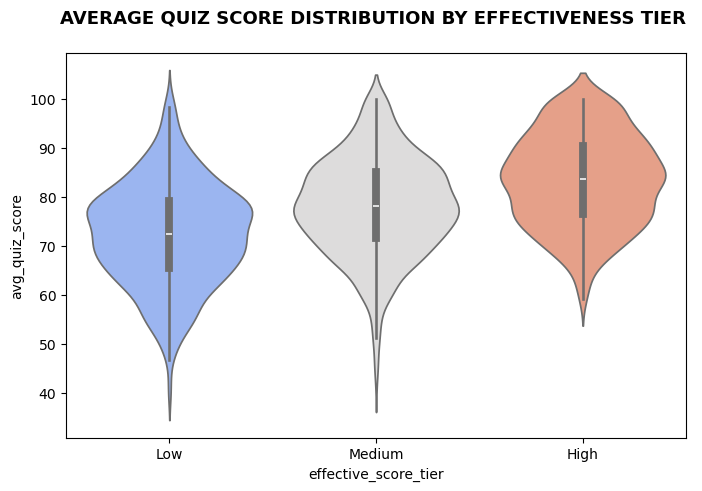

In [153]:
# completion rate for each effectiveness tier

plt.figure(figsize=(8,5))
sns.violinplot(data=data,x='effective_score_tier',y='avg_quiz_score',order=['Low','Medium','High'],palette='coolwarm')
plt.title('AVERAGE QUIZ SCORE DISTRIBUTION BY EFFECTIVENESS TIER \n',fontsize=13, fontweight='bold')
plt.show()

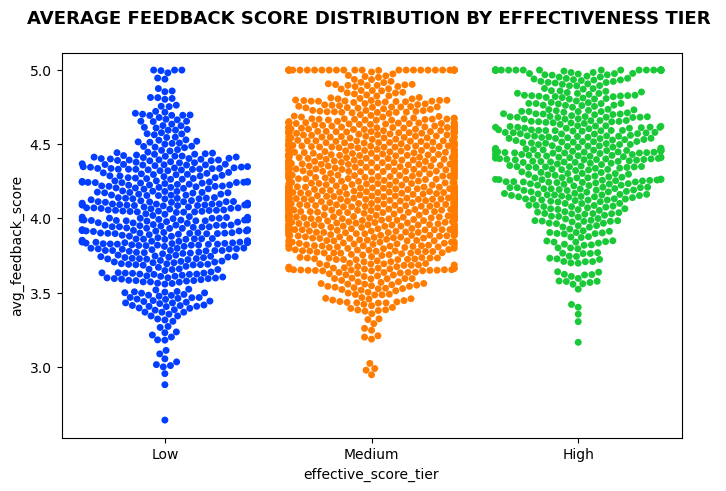

In [154]:
# average feedback score for each effectiveness tier

plt.figure(figsize=(8,5))
sns.swarmplot(data=data,x='effective_score_tier',y='avg_feedback_score',order=['Low','Medium','High'],palette='bright')
plt.title('AVERAGE FEEDBACK SCORE DISTRIBUTION BY EFFECTIVENESS TIER \n',fontsize=13, fontweight='bold')
plt.show()

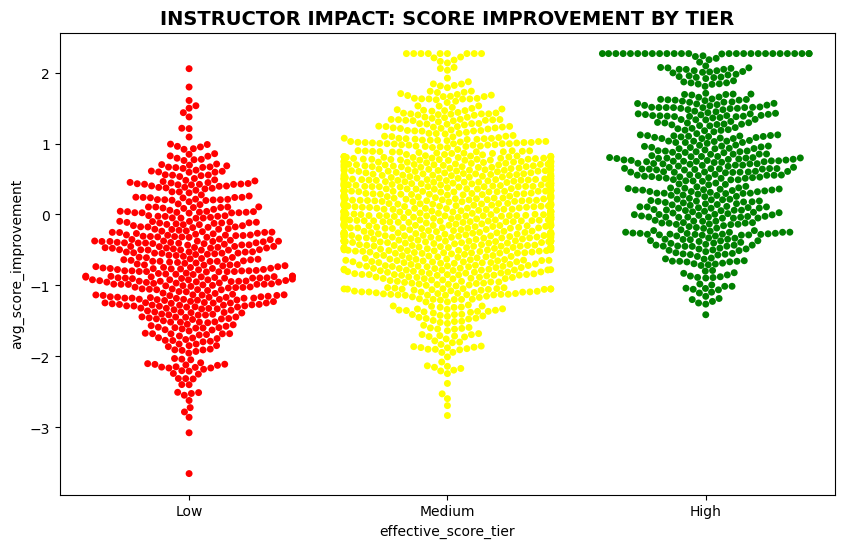

In [155]:
# average feedback score for each effectiveness tier

plt.figure(figsize=(10, 6))
# Violin plot for density, inner=None hata kar 'quart' daal dein agar boxplot bhi chahiye
sns.swarmplot(x='effective_score_tier', y='avg_score_improvement', data=df, order=['Low', 'Medium', 'High'], palette=['red','yellow','green'])
plt.title('INSTRUCTOR IMPACT: SCORE IMPROVEMENT BY TIER', fontsize=14, fontweight='bold')
plt.show()

<Axes: >

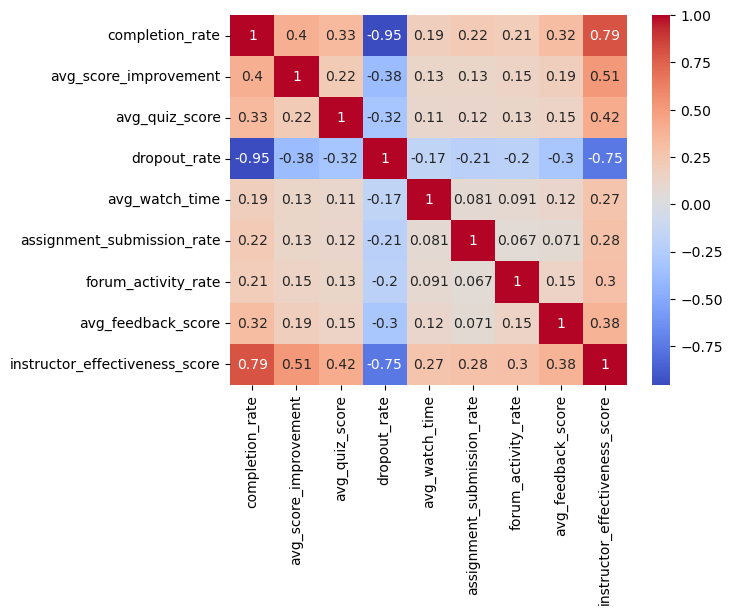

In [156]:
# Correlation Heatmap

cols = ['completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 
        'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 
        'avg_feedback_score', 'instructor_effectiveness_score']

sns.heatmap(data[cols].corr(),annot=True, cmap='coolwarm')

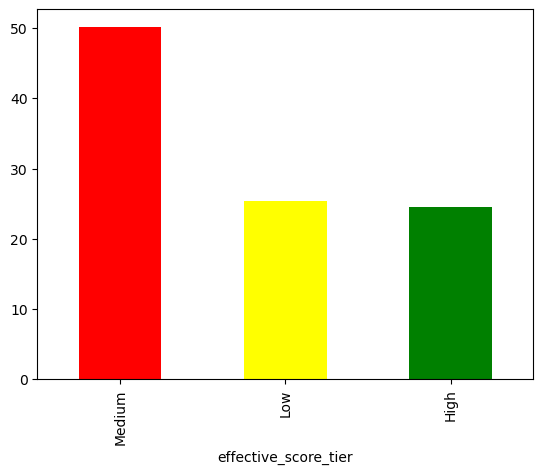

In [157]:
# looking for distribution of the target variable in percentage

(data['effective_score_tier'].value_counts(normalize=True)*100).plot(kind='bar', color=['red','yellow','green'])
plt.show()

***

***FINAL INSIGHTS***

* After visualization , I identifies that medium tier is highly densed than the other 2.
* As we know there is strong correlation between completion_rate and dropout_rate so, I am taking only completion rate for model prediction
* Through this correlation I can identify that completion_rate,avg_score_improvement and avg_quiz_score are most important features for score calculation because it is highly correlated than the other columns. So, these features would be our important factors for building a model.
* before creating a model I need to encode the target variable that is effective_score_tier and droping columns like id's,dropout_rate,instructor_effective_score
* As we have our target column is categorical we use classification model here and This variable has more than 2 classes so we are using multiclass classification model where classification report is the important output for our model
* As there is slightly a class imbalance in target variable we can see that medium has 50% of the data while others has 25% or less.So, we need to use class_weight='balanced' parameter at the time of training the model.


***

### Model Prediction

In [158]:
# scaling the effective_score_tier variable

encode= LabelEncoder()
df['effective_score_tier'] = encode.fit_transform(df['effective_score_tier'])

In [159]:
# splitting the data

x = df.drop(columns= ['instructor_id', 'batch_id', 'course_id', 'effective_score_tier','instructor_effectiveness_score','dropout_rate'])
y = df['effective_score_tier']

In [160]:
# train test split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [161]:
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (1600, 8)
X_test shape: (400, 8)
y_train shape: (1600,)
y_test shape: (400,)


##### Logistic Regression(Baseline Model)

In [162]:
model_lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000,class_weight='balanced')
model_lr.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

In [163]:
# predicting the values

model_pred = model_lr.predict(x_test)

In [164]:
# score calculation


print('-'*50 , 'MODEL PERFORMANCE' , '-'*50,'\n')

print("Accuracy Score:", accuracy_score(y_test, model_pred))
print('F1_score', f1_score(y_test, model_pred, average='macro'))
print("\nClassification Report:\n")
print(classification_report(y_test, model_pred))

-------------------------------------------------- MODEL PERFORMANCE -------------------------------------------------- 

Accuracy Score: 0.7125
F1_score 0.7213704660733083

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.75      0.72       116
           1       0.75      0.82      0.78       103
           2       0.71      0.63      0.67       181

    accuracy                           0.71       400
   macro avg       0.71      0.73      0.72       400
weighted avg       0.71      0.71      0.71       400



In [165]:
# Looking for train score 

model_pred_train = model_lr.predict(x_train)

print(" Test Accuracy Score:", accuracy_score(y_test, model_pred))
print(" Train Accuracy Score:", accuracy_score(y_train, model_pred_train))


 Test Accuracy Score: 0.7125
 Train Accuracy Score: 0.71625


As I can identify that our model accuracy is 71 percent and our accuracy and precision in each class is good but in medium our model can only predict 61 out of 100 samples . As our model is generalized there is no issue of overfitting or underfitting because our train score is 70% and ourtest score is also around 71 percent. But our accuracy is low . I am taking some complex models If those models score is lower than logisctic model . I will take this model as my final model for prediction.

##### Random Forest Classifier

In [166]:
params = {'n_estimators': [100,120,150,170,210],'max_depth':[2,5,7,9,11],'min_samples_split':[2,5,7]}

model = RandomForestClassifier(class_weight = 'balanced',random_state=42)

grid_cv = GridSearchCV(estimator=model, param_grid=params, cv=5, n_jobs=-1, verbose=2,scoring='roc_auc_ovr')

In [167]:
grid_cv.fit(x_train, y_train)

best_model = grid_cv.best_estimator_

Fitting 5 folds for each of 75 candidates, totalling 375 fits


In [168]:
print(best_model)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=5, n_estimators=210, random_state=42)


In [169]:
model_pred_rf = best_model.predict(x_test)

print('-'*50 , 'MODEL PERFORMANCE' , '-'*50,'\n')

print("Accuracy Score:", accuracy_score(y_test, model_pred_rf))
print('F1_score', f1_score(y_test, model_pred_rf, average='macro'))
print('Roc_auc_Score',grid_cv.best_score_)
print("\nClassification Report:\n")
print(classification_report(y_test, model_pred_rf))

-------------------------------------------------- MODEL PERFORMANCE -------------------------------------------------- 

Accuracy Score: 0.71
F1_score 0.7165383798726035
Roc_auc_Score 0.8749695675157481

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.66      0.69       116
           1       0.73      0.83      0.78       103
           2       0.69      0.67      0.68       181

    accuracy                           0.71       400
   macro avg       0.71      0.72      0.72       400
weighted avg       0.71      0.71      0.71       400



#### XG Boost Classifier

In [170]:
params = {'n_estimators': [100,120,150,170],'max_depth':[2,5,7,9],'min_child_weight':[2,5,7],
          'learning_rate':[0.01,0.015],'subsample':[0.8,1.0]}

model_xgb = XGBClassifier(class_weight = 'balanced',random_state=42,objective = 'multi:softprob',eval_metric = 'mlogloss')

grid_cv = GridSearchCV(estimator=model_xgb, param_grid=params, cv=5, n_jobs=-1, verbose=2,scoring='roc_auc_ovr')

In [171]:
grid_cv.fit(x_train, y_train)

best_model_xg = grid_cv.best_estimator_

Fitting 5 folds for each of 192 candidates, totalling 960 fits


In [172]:
print(best_model_xg)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.015, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=170, n_jobs=None, ...)


In [173]:
model_pred_xg = best_model_xg.predict(x_test)
print('-'*50 , 'MODEL PERFORMANCE' , '-'*50,'\n')

print("Accuracy Score:", accuracy_score(y_test, model_pred_xg))
print('F1_score', f1_score(y_test, model_pred_xg, average='macro'))
print('Roc_auc_Score',grid_cv.best_score_)
print("\nClassification Report:\n")
print(classification_report(y_test, model_pred_xg))

-------------------------------------------------- MODEL PERFORMANCE -------------------------------------------------- 

Accuracy Score: 0.7125
F1_score 0.705422211925233
Roc_auc_Score 0.8726370127361507

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.57      0.67       116
           1       0.84      0.62      0.72       103
           2       0.64      0.86      0.73       181

    accuracy                           0.71       400
   macro avg       0.76      0.68      0.71       400
weighted avg       0.74      0.71      0.71       400



### Models Scorecard

In [174]:


results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.712, 0.71, 0.712],
    'Roc_AUC_Score':[0.87,0.875,0.873],
    'F1-Score (Macro)': [0.721, 0.716, 0.705]}
    


df_results = pd.DataFrame(results)


display(df_results)

,Model,Accuracy,Roc_AUC_Score,F1-Score (Macro)
0,Logistic Regression,0.712,0.870,0.721
1,Random Forest,0.710,0.875,0.716
2,XGBoost,0.712,0.873,0.705


#### Final Model

After getting scorecard of all these models. I found Random forest as my final model for prediction because it's roc_auc is more than the other 2. However, it's accuracy is less than others but due to high roc_auc I need to choose this as a final model.

In [175]:
final_model = RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=5, n_estimators=210, random_state=42)

model_rf = final_model.fit(x_train,y_train)

model_pred_rf = model_rf.predict(x_test)

print('-'*50 , 'MODEL PERFORMANCE OF TEST SCORE' , '-'*50,'\n')

print("Accuracy Score:", accuracy_score(y_test, model_pred_rf))
print('F1_score', f1_score(y_test, model_pred_rf, average='macro'))
print("\nClassification Report:\n")
print(classification_report(y_test, model_pred_rf))




-------------------------------------------------- MODEL PERFORMANCE OF TEST SCORE -------------------------------------------------- 

Accuracy Score: 0.71
F1_score 0.7165383798726035

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.66      0.69       116
           1       0.73      0.83      0.78       103
           2       0.69      0.67      0.68       181

    accuracy                           0.71       400
   macro avg       0.71      0.72      0.72       400
weighted avg       0.71      0.71      0.71       400



In [176]:
final_model = RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=5, n_estimators=210, random_state=42)

model_rf = final_model.fit(x_train,y_train)

model_pred_train = model_rf.predict(x_train)

print('-'*50 , 'MODEL PERFORMANCE OF TRAIN SCORE' , '-'*50,'\n')

print("Accuracy Score:", accuracy_score(y_train, model_pred_train))
print('F1_score', f1_score(y_train, model_pred_train, average='macro'))
print("\nClassification Report:\n")
print(classification_report(y_train, model_pred_train))


-------------------------------------------------- MODEL PERFORMANCE OF TRAIN SCORE -------------------------------------------------- 

Accuracy Score: 0.793125
F1_score 0.793792277038151

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.81      0.78       373
           1       0.75      0.87      0.81       405
           2       0.84      0.75      0.79       822

    accuracy                           0.79      1600
   macro avg       0.78      0.81      0.79      1600
weighted avg       0.80      0.79      0.79      1600



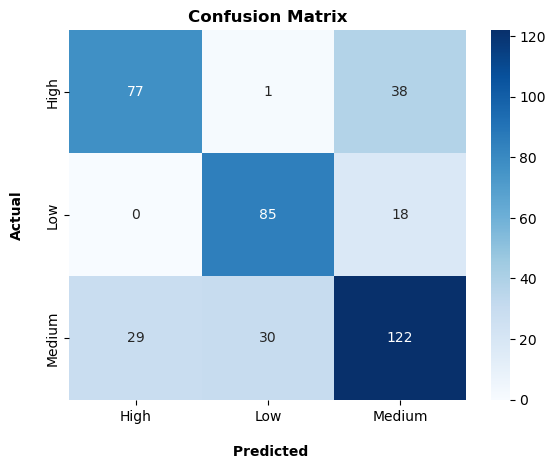

In [177]:
# Visualizing confusion Matrix

cm = confusion_matrix(y_test, model_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['High', 'Low', 'Medium'], 
            yticklabels=['High', 'Low', 'Medium'])
plt.ylabel('Actual\n ',fontweight='bold')
plt.xlabel('\n Predicted',fontweight='bold')
plt.title('Confusion Matrix',fontweight='bold')
plt.show()

#### FEATURE IMPORTANCE

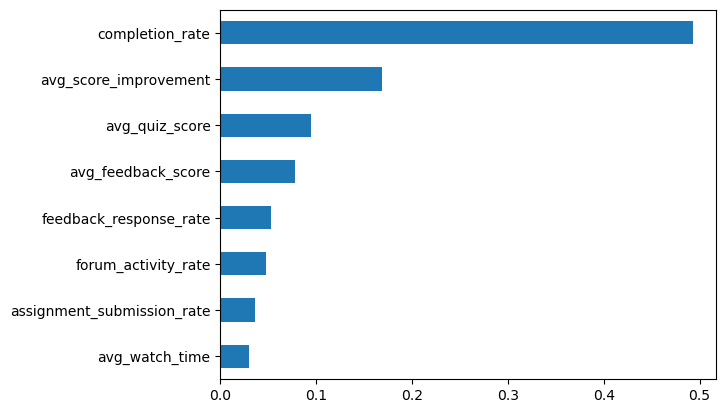

In [178]:

pd.Series(final_model.feature_importances_, index=x_train.columns).sort_values().plot(kind='barh')
plt.show()

***
***

### CONCLUSION

* In the model creation all these models are performing well I can't say that any one of them is not able to my prediction accurately but if i need to choose any one model out of all these I prefer to choose random Forest because It reduces issue of overfitting in the model and it's roc_auc_score is better than others.

* By looking the feature importance of the model. I found that completion rate is the most important feature for prediction and assignment_submission_rate
 and avg_watch_time is very less important feature. So, if i remove these 2 feature from model prediction. My model can also work well without these two.


 ***Actionable Insights***

* We need to more focus on completion rate and less focus on assignment_submission_rate and avg_watch_time. This means the company need to focus to complete the task or videos rather than only watching it.
* As we earlier, said that there is strong correlation between completion rate and drop_out rate. So, the platform need to provide more priority for completion_rate and try to reduce the drop_out rate so that the completion_rate goes high. This will lead to grow the learners in a fast pace.
* The ssecond most important factor is average_score_improvement. The platform tries to focus more on score improvement for learners . This will reduce the dropout rate because retention and completion is positively related to each other.
* According to me, platform need to shift from avg_watch_time to completion_rate.

 



***
***

#### Questions to Answer

1) Which features most influenced instructor effectiveness, and why? 

    The Most influencing feature for instructor effectiveness score is completion_rate because data shows that when the dropout rate decreases there is high chance of completing the task or project and this leads to grow the performance of learners which increases the instructor score.
    

2. Which variables could be misleading or confounded? 

    The variable which is misleading is avg_watch_time. The platform don't need to waste money on avg_watch_time. Because It is less connected with instructor score and learner preformance.

3. How could this model fail in real-world usage? 

    My model provide 87 percent roc score. But, it could be fail in the real world usage when there is a change in the pattern of the data. As the time passes this can possible that the model became outdated due to this my model can't predict accurately on new and unseen data . May be if any other factor effects the dropout rate and completion rate by learners. So, those external factors can create biasness. We need to keep updated this model so that these challenges which we can face in real world usage can resolved.

4. What additional data would you want to improve this analysis? 

    - I need background information of students so, that I can properly examine that any external factors effected the learner performance or not.
    - I also need to find that the quality and depth of the data.
    - I also need to find the teaching style of the instructors . This will help me to identify the reason of less completion rate more accurately.
    -  I also need to know about each batch details like the number of learners in each batch course provide for that batch. This will also help me to analyse the data much more better.


5. Should this model be used for instructor performance evaluation? Why or why not? 

    No, I can;t use this model for instructor performance evaluation . As, I already specify that there can be other factors which influenced the instructor performance . We don't have any detailed information of this data and the other factors which effect this data like teaching style details and learner background etc. As this model is only performing the learner performance not directly able to predict the teaching quality of instructor. So, I cannot directly take this model for my instructor performance evalueation.
    